# Pratica: Random Walk e Monte Carlo (versao comentada)

Este notebook foi escrito do zero e comenta o codigo em detalhes para estudo.

Objetivos:
- Gerar numeros pseudoaleatorios com LCG
- Simular random walks 1D
- Medir MSD e ajustar lei de potencia
- Fazer teste de hipotese para alpha
- Verificar TCL com muitas amostras

In [8]:
# Importa funcoes do sistema operacional (ex.: criar pastas)
import os

# Importa biblioteca para escrita/leitura de CSV
import csv

# Importa classe para manipular caminhos com seguranca
from pathlib import Path

# Importa biblioteca numerica principal
import numpy as np

# Importa biblioteca para graficos
import matplotlib.pyplot as plt

# Importa modulos estatisticos (regressao, distribuicoes, testes)
from scipy import stats

# Cria a pasta de graficos se ela nao existir
os.makedirs('graficos', exist_ok=True)

# Define a pasta de dados como um objeto Path
DATA_DIR = Path('dados')

# Define subpastas para separar entradas e saidas
INPUT_DIR = DATA_DIR / 'input'
OUTPUT_DIR = DATA_DIR / 'output'

# Cria as pastas de entrada e saida se nao existirem
INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Ajusta tamanho padrao das figuras
plt.rcParams['figure.figsize'] = (12, 5)

# Ajusta tamanho padrao da fonte
plt.rcParams['font.size'] = 12

# Liga grade automaticamente nos eixos
plt.rcParams['axes.grid'] = True

# Define transparencia da grade
plt.rcParams['grid.alpha'] = 0.3

In [9]:
# Define funcao para salvar dados em formato de linhas no CSV
def save_rows_csv(path, header, rows):
    # Abre (ou cria) o arquivo em modo escrita
    # newline='' evita linhas em branco extras no Windows
    with path.open('w', newline='', encoding='utf-8') as csvfile:
        # Cria o escritor CSV
        writer = csv.writer(csvfile)

        # Escreve a linha de cabecalho
        writer.writerow(header)

        # Escreve todas as linhas de dados
        writer.writerows(rows)

# Define funcao para salvar dados em formato de colunas no CSV
def save_columns_csv(path, columns):
    # Extrai os nomes das colunas (chaves do dicionario)
    headers = list(columns.keys())

    # Converte cada coluna para lista e combina colunas em linhas
    # Exemplo: A=[1,2], B=[3,4] vira linhas (1,3) e (2,4)
    rows = zip(*(np.asarray(column).tolist() for column in columns.values()))

    # Reaproveita a funcao anterior para gravar o arquivo
    save_rows_csv(path, headers, rows)

## 1) Gerador Congruencial Linear (LCG)

Vamos usar o LCG para gerar numeros em [0, 1), depois converter em passos +1 ou -1.

In [10]:
# Define multiplicador do LCG (Numerical Recipes)
LCG_A = 1664525

# Define incremento do LCG
LCG_C = 1013904223

# Define modulo do LCG
LCG_M = 2**32

# Define funcao LCG
def lcg(seed, n, a=LCG_A, c=LCG_C, m=LCG_M):
    # Cria array para guardar n numeros uniformes
    u = np.empty(n)

    # Ajusta seed para o intervalo valido do modulo
    x = int(seed) % m

    # Repete n vezes para gerar a sequencia
    for i in range(n):
        # Atualiza estado interno com a recorrencia do LCG
        x = (a * x + c) % m

        # Normaliza para o intervalo [0, 1)
        u[i] = x / m

    # Retorna vetor de uniformes
    return u

# Define funcao para simular random walk 1D
def random_walk_1d(seed, n_steps):
    # Gera n_steps uniformes usando a seed fornecida
    u = lcg(seed=seed, n=n_steps)

    # Converte cada numero em passo: +1 se < 0.5, senao -1
    steps = np.where(u < 0.5, +1, -1)

    # Soma acumulada dos passos e adiciona posicao inicial x(0)=0
    x = np.concatenate([[0], np.cumsum(steps)])

    # Retorna trajetoria completa
    return x

# Teste rapido do LCG com 10 numeros
u_teste = lcg(seed=42, n=10)

# Mostra os 10 primeiros valores arredondados
print('Primeiros 10 valores uniformes do LCG:')
print(np.round(u_teste, 4))

Primeiros 10 valores uniformes do LCG:
[0.2523 0.0881 0.5773 0.2226 0.3757 0.0257 0.4473 0.1185 0.8738 0.9946]


## 2) Simulacao de 10 caminhadas e grafico

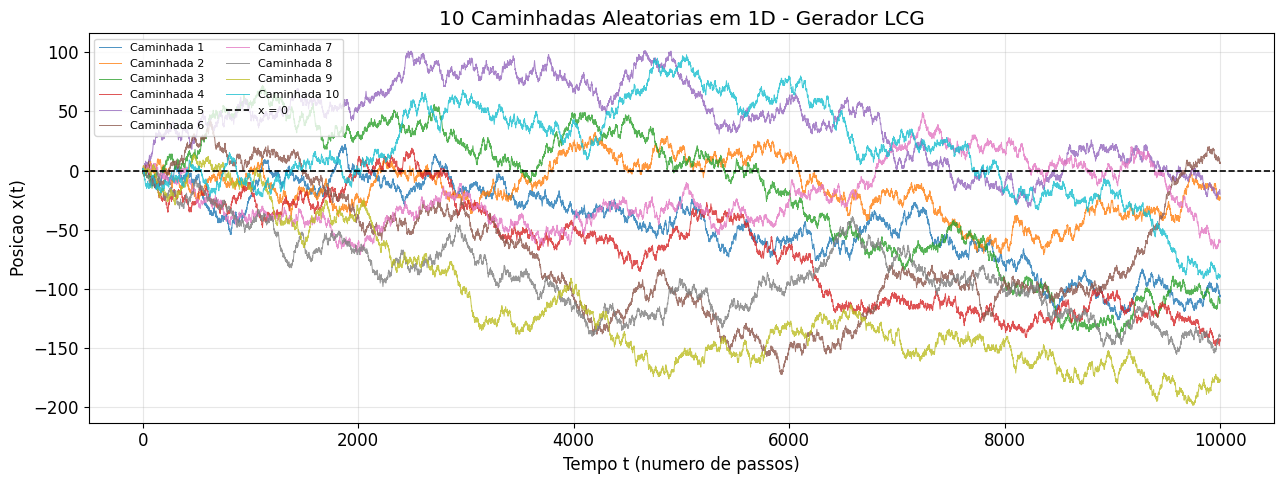

CSV salvo em dados/entrada_parametros.csv e dados/saida_trajetorias.csv


In [11]:
# Define quantidade de caminhadas independentes
N_WALKS = 10

# Define quantidade de passos por caminhada
N_STEPS = 10000

# Cria vetor de tempo de 0 ate N_STEPS
t = np.arange(N_STEPS + 1)

# Gera seeds diferentes de forma deterministica
# (pode trocar 12345 por outro inteiro positivo)
seeds_walks = [(i + 1) * 12345 for i in range(N_WALKS)]

# Prepara tabela de parametros de entrada
entrada_rows = [
    ['N_WALKS', N_WALKS],
    ['N_STEPS', N_STEPS],
    ['LCG_A', LCG_A],
    ['LCG_C', LCG_C],
    ['LCG_M', LCG_M],
]

# Adiciona uma linha para cada seed usada
entrada_rows.extend([[f'seed_walk_{i+1}', seed] for i, seed in enumerate(seeds_walks)])

# Salva parametros no CSV de entrada
save_rows_csv(INPUT_DIR / 'entrada_parametros.csv', ['parametro', 'valor'], entrada_rows)

# Cria matriz para guardar todas as trajetorias
trajetorias = np.zeros((N_WALKS, N_STEPS + 1))

# Simula cada caminhada com sua seed
for i, seed_i in enumerate(seeds_walks):
    trajetorias[i] = random_walk_1d(seed=seed_i, n_steps=N_STEPS)

# Cria figura e eixo para o grafico das trajetorias
fig, ax = plt.subplots(figsize=(13, 5))

# Plota cada caminhada no mesmo eixo
for i in range(N_WALKS):
    ax.plot(t, trajetorias[i], lw=0.7, alpha=0.8, label=f'Caminhada {i+1}')

# Linha horizontal de referencia em x=0
ax.axhline(0, color='black', lw=1.2, linestyle='--', label='x = 0')

# Rotulos dos eixos
ax.set_xlabel('Tempo t (numero de passos)')
ax.set_ylabel('Posicao x(t)')

# Titulo do grafico
ax.set_title('10 Caminhadas Aleatorias em 1D - Gerador LCG')

# Mostra legenda
ax.legend(loc='upper left', fontsize=8, ncol=2)

# Ajusta layout para evitar corte de texto
plt.tight_layout()

# Salva imagem em arquivo
plt.savefig('graficos/caminhadas.png', dpi=150)

# Exibe figura na tela
plt.show()

# Monta dicionario de colunas para salvar todas as trajetorias
trajetorias_columns = {'tempo': t}
trajetorias_columns.update({f'caminhada_{i+1}': trajetorias[i] for i in range(N_WALKS)})

# Salva trajetorias no CSV de saida
save_columns_csv(OUTPUT_DIR / 'saida_trajetorias.csv', trajetorias_columns)

# Mensagem final desta etapa
print('CSV salvo em dados/entrada_parametros.csv e dados/saida_trajetorias.csv')

## 3) MSD e ajuste log-log

Expoente estimado : alpha = 1.0168
Constante         : C = 0.9261
R2 do ajuste      : 0.960827
Erro padrao alpha : 0.002053


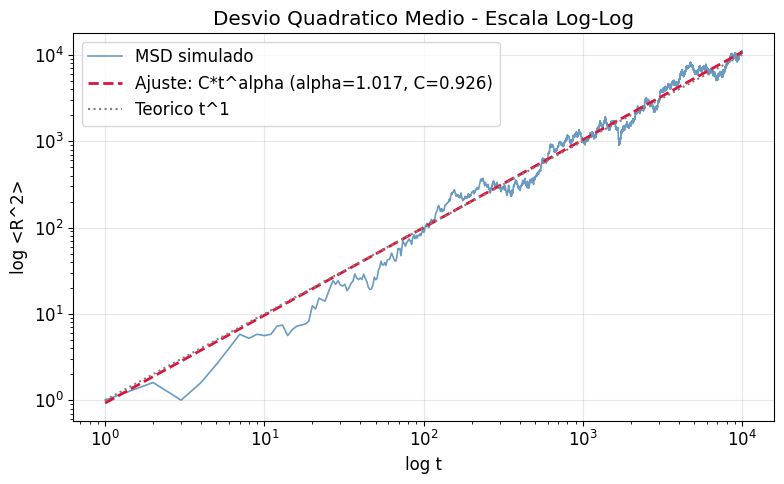

In [12]:
# Calcula MSD medio sobre as caminhadas: <x(t)^2>
msd = np.mean(trajetorias**2, axis=0)

# Remove t=0 para evitar log(0)
t_fit = t[1:]
msd_fit = msd[1:]

# Aplica log natural nos dados
log_t = np.log(t_fit)
log_msd = np.log(msd_fit)

# Faz regressao linear em log-log
slope, intercept, r_value, p_value, std_err = stats.linregress(log_t, log_msd)

# Slope vira alpha e exp(intercept) vira C
alpha_est = slope
C_est = np.exp(intercept)

# Mostra parametros estimados
print(f'Expoente estimado : alpha = {alpha_est:.4f}')
print(f'Constante         : C = {C_est:.4f}')
print(f'R2 do ajuste      : {r_value**2:.6f}')
print(f'Erro padrao alpha : {std_err:.6f}')

# Calcula curva ajustada C * t^alpha
msd_ajustado = C_est * t_fit**alpha_est

# Cria vetor completo para salvar (com NaN em t=0)
msd_ajuste_completo = np.full_like(msd, np.nan, dtype=float)
msd_ajuste_completo[1:] = msd_ajustado

# Salva serie do MSD em CSV
save_columns_csv(
    OUTPUT_DIR / 'saida_msd.csv',
    {'tempo': t, 'msd': msd, 'msd_ajuste_potencia': msd_ajuste_completo},
)

# Plota dados e ajuste em escala log-log
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(t_fit, msd_fit, color='steelblue', lw=1.2, alpha=0.8, label='MSD simulado')
ax.loglog(t_fit, msd_ajustado, color='crimson', lw=2, linestyle='--', label=f'Ajuste: C*t^alpha (alpha={alpha_est:.3f}, C={C_est:.3f})')
ax.loglog(t_fit, t_fit, color='gray', lw=1.5, linestyle=':', label='Teorico t^1')

# Configura eixos e titulo
ax.set_xlabel('log t')
ax.set_ylabel('log <R^2>')
ax.set_title('Desvio Quadratico Medio - Escala Log-Log')
ax.legend()

# Ajusta layout, salva e mostra
plt.tight_layout()
plt.savefig('graficos/msd_loglog.png', dpi=150)
plt.show()

## 4) Teste de hipotese para alpha

In [13]:
# Define valor teorico para alpha sob H0
alpha_0 = 1.0

# Define nivel de significancia de 5%
nivel_sig = 0.05

# Numero de pontos usados na regressao
n_pontos = len(log_t)

# Graus de liberdade da regressao linear
gl = n_pontos - 2

# Estatistica t para testar alpha_est contra alpha_0
t_stat = (alpha_est - alpha_0) / std_err

# Valor critico bicaudal para 5%
t_critico = stats.t.ppf(1 - nivel_sig / 2, df=gl)

# p-valor bicaudal
p_valor = 2 * stats.t.sf(abs(t_stat), df=gl)

# Imprime resultados do teste
print('=' * 50)
print('TESTE DE HIPOTESE - EXPOENTE alpha')
print('=' * 50)
print(f'H0: alpha = {alpha_0}  vs  H1: alpha != {alpha_0}')
print(f'alpha estimado  : {alpha_est:.6f}')
print(f'Erro padrao     : {std_err:.6f}')
print(f'Estatistica t   : {t_stat:.4f}')
print(f'Graus de liber. : {gl}')
print(f't critico (5%)  : +/-{t_critico:.4f}')
print(f'p-valor         : {p_valor:.6f}')
print('-' * 50)

# Toma decisao comparando |t_stat| com t_critico
if abs(t_stat) < t_critico:
    print('CONCLUSAO: NAO rejeitamos H0.')
    print('alpha e compativel com 1 (random walk puro).')
else:
    print('CONCLUSAO: REJEITAMOS H0.')
    print('alpha difere significativamente de 1.')

print('=' * 50)

# Salva resumo do teste em CSV
save_rows_csv(
    OUTPUT_DIR / 'saida_teste_hipotese.csv',
    ['alpha_est', 'C_est', 'r2_ajuste', 'std_err_alpha', 't_stat', 't_critico', 'p_valor', 'graus_liberdade'],
    [[alpha_est, C_est, r_value**2, std_err, t_stat, t_critico, p_valor, gl]],
)

# Mensagem final desta etapa
print('CSV salvo em dados/saida_teste_hipotese.csv')

TESTE DE HIPOTESE - EXPOENTE alpha
H0: alpha = 1.0  vs  H1: alpha != 1.0
alpha estimado  : 1.016797
Erro padrao     : 0.002053
Estatistica t   : 8.1807
Graus de liber. : 9998
t critico (5%)  : +/-1.9602
p-valor         : 0.000000
--------------------------------------------------
CONCLUSAO: REJEITAMOS H0.
alpha difere significativamente de 1.
CSV salvo em dados/saida_teste_hipotese.csv


## 5) Verificacao do TCL

Media de Z      : -0.0001  (esperado: 0)
Desvio padrao Z : 0.9863   (esperado: 1)


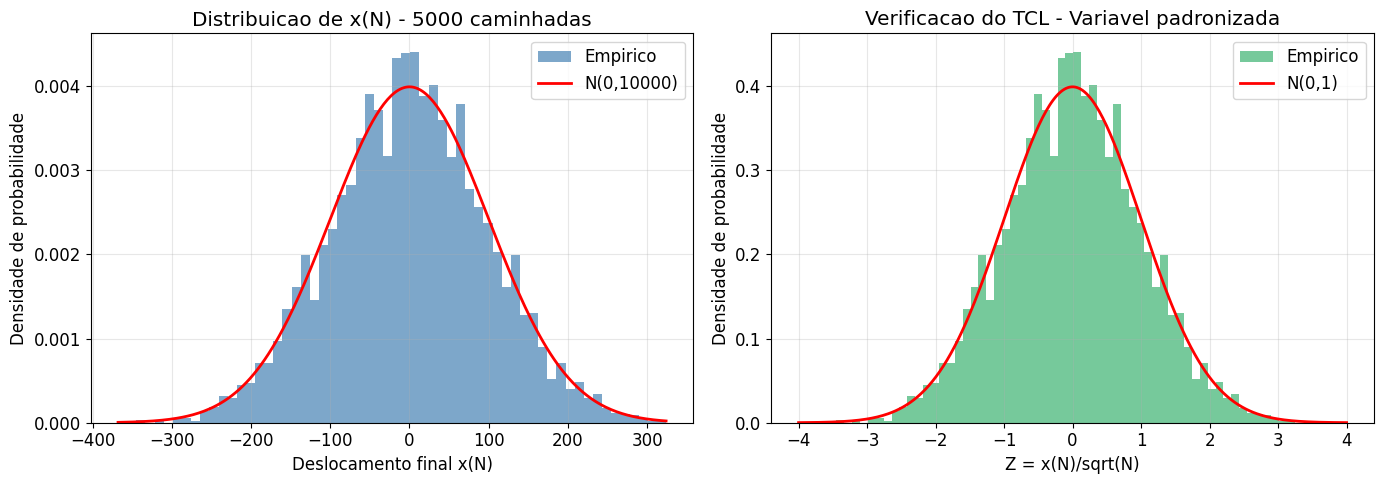


Teste Kolmogorov-Smirnov (Z vs N(0,1)):
  KS statistic : 0.0127
  p-valor      : 0.3895
  Nao rejeitamos normalidade. TCL verificado!
CSVs salvos em dados/entrada_tcl_parametros.csv, dados/saida_tcl_amostras.csv e dados/saida_tcl_resumo.csv


In [14]:
# Define numero de caminhadas para experimento do TCL
N_TCL = 5000

# Usa mesmo numero de passos da simulacao principal
N_STEPS_TCL = N_STEPS

# Salva parametros de entrada do TCL
save_rows_csv(
    INPUT_DIR / 'entrada_tcl_parametros.csv',
    ['parametro', 'valor'],
    [
        ['N_TCL', N_TCL],
        ['N_STEPS_TCL', N_STEPS_TCL],
        ['seed_formula', '(i + 1) * 9973'],
    ],
)

# Cria vetor para guardar deslocamentos finais x(N)
deslocamentos_finais = np.zeros(N_TCL)

# Gera N_TCL caminhadas independentes e guarda apenas x(N)
for i in range(N_TCL):
    # Define seed da caminhada i
    seed_i = (i + 1) * 9973

    # Gera uniformes para N passos
    u = lcg(seed=seed_i, n=N_STEPS_TCL)

    # Converte em passos +/-1
    steps = np.where(u < 0.5, +1, -1)

    # Soma passos para obter deslocamento final
    deslocamentos_finais[i] = steps.sum()

# Padroniza deslocamentos: Z = x(N) / sqrt(N)
Z = deslocamentos_finais / np.sqrt(N_STEPS_TCL)

# Mostra estatisticas basicas de Z
print(f'Media de Z      : {Z.mean():.4f}  (esperado: 0)')
print(f'Desvio padrao Z : {Z.std():.4f}   (esperado: 1)')

# Cria figura com 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Primeiro grafico: histograma de x(N) e curva normal N(0, N)
ax = axes[0]
x_grid = np.linspace(deslocamentos_finais.min(), deslocamentos_finais.max(), 300)
gauss_bruta = stats.norm.pdf(x_grid, loc=0, scale=np.sqrt(N_STEPS_TCL))
ax.hist(deslocamentos_finais, bins=60, density=True, color='steelblue', alpha=0.7, label='Empirico')
ax.plot(x_grid, gauss_bruta, 'r-', lw=2, label=f'N(0,{N_STEPS_TCL})')
ax.set_xlabel('Deslocamento final x(N)')
ax.set_ylabel('Densidade de probabilidade')
ax.set_title(f'Distribuicao de x(N) - {N_TCL} caminhadas')
ax.legend()

# Segundo grafico: histograma de Z e curva normal padrao N(0,1)
ax = axes[1]
z_grid = np.linspace(-4, 4, 300)
gauss_std = stats.norm.pdf(z_grid)
ax.hist(Z, bins=60, density=True, color='mediumseagreen', alpha=0.7, label='Empirico')
ax.plot(z_grid, gauss_std, 'r-', lw=2, label='N(0,1)')
ax.set_xlabel('Z = x(N)/sqrt(N)')
ax.set_ylabel('Densidade de probabilidade')
ax.set_title('Verificacao do TCL - Variavel padronizada')
ax.legend()

# Ajusta layout, salva e mostra figura
plt.tight_layout()
plt.savefig('graficos/tcl.png', dpi=150)
plt.show()

# Executa teste KS para comparar Z com N(0,1)
ks_stat, ks_pvalor = stats.kstest(Z, 'norm')

# Imprime resultado do teste KS
print()
print('Teste Kolmogorov-Smirnov (Z vs N(0,1)):')
print(f'  KS statistic : {ks_stat:.4f}')
print(f'  p-valor      : {ks_pvalor:.4f}')

# Interpreta p-valor ao nivel de 5%
if ks_pvalor > 0.05:
    print('  Nao rejeitamos normalidade. TCL verificado!')
else:
    print('  Rejeitamos normalidade ao nivel de 5%.')

# Salva amostras individuais do TCL
save_columns_csv(
    OUTPUT_DIR / 'saida_tcl_amostras.csv',
    {'deslocamento_final': deslocamentos_finais, 'z_padronizado': Z},
)

# Salva resumo numerico do TCL
save_rows_csv(
    OUTPUT_DIR / 'saida_tcl_resumo.csv',
    ['media_Z', 'desvio_padrao_Z', 'ks_stat', 'ks_pvalor'],
    [[Z.mean(), Z.std(), ks_stat, ks_pvalor]],
)

# Mensagem final desta etapa
print('CSVs salvos em dados/entrada_tcl_parametros.csv, dados/saida_tcl_amostras.csv e dados/saida_tcl_resumo.csv')

## Resumo rapido

- LCG gera uniformes em [0,1)
- Random walk 1D usa passos +1/-1
- MSD em log-log estima alpha
- Teste t checa compatibilidade com alpha=1
- TCL compara distribuicao padronizada com N(0,1)